In [1]:
# =====================================================
# EDA - Datos Climáticos Cacao
# Metodología: CRISP-DM
# Fase: Preparación de los Datos (EDA)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Configuración visual
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_style("whitegrid")

# Subir archivo desde el computador
uploaded = files.upload()

# Detectar nombre del archivo cargado
file_name = list(uploaded.keys())[0]
print(f"Archivo cargado: {file_name}")

# Leer archivo Excel
df = pd.read_excel(file_name)

# Vista inicial
df.head()


Saving Data_Consolidada_Variables_Sin_Limpiar.xlsx to Data_Consolidada_Variables_Sin_Limpiar.xlsx
Archivo cargado: Data_Consolidada_Variables_Sin_Limpiar.xlsx


,Fecha,Mes,Año,Día,PRECIPITACIÓN,TMAX,TMIN,TPROM,HR,RAD_SOL,EVPTRNS,VDL
0,2010-01-01,1,2010,1,0.00,27.51,10.47,18.99,61.57,21.92,3.93,0.84
1,2010-01-02,1,2010,2,0.00,28.04,12.77,20.41,58.46,21.59,3.33,1.00
2,2010-01-03,1,2010,3,0.00,28.26,10.05,19.16,54.09,22.92,2.92,1.02
3,2010-01-04,1,2010,4,0.00,27.82,12.38,20.10,50.96,21.90,2.43,1.15
4,2010-01-05,1,2010,5,0.00,28.90,13.38,21.14,54.18,22.44,2.22,1.15


In [2]:
# Estructura general del dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5293 entries, 0 to 5292
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Fecha          5293 non-null   datetime64[ns]
 1   Mes            5293 non-null   int64         
 2   Año            5293 non-null   int64         
 3   Día            5293 non-null   int64         
 4   PRECIPITACIÓN  5293 non-null   float64       
 5   TMAX           5293 non-null   float64       
 6   TMIN           5293 non-null   float64       
 7   TPROM          5293 non-null   float64       
 8   HR             5293 non-null   float64       
 9   RAD_SOL        5293 non-null   float64       
 10  EVPTRNS        5293 non-null   float64       
 11  VDL            5293 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(3)
memory usage: 496.3 KB


In [3]:
# Estadísticos descriptivos
df.describe()


,Fecha,Mes,Año,Día,PRECIPITACIÓN,TMAX,TMIN,TPROM,HR,RAD_SOL,EVPTRNS,VDL
count,5293,5293.00,5293.00,5293.00,5293.00,5293.00,5293.00,5293.00,5293.00,5293.00,5293.00,5293.00
mean,2017-05-13 07:41:57.211411456,6.59,2016.86,15.73,3.95,25.58,16.07,20.83,77.45,18.31,3.35,0.57
min,2010-01-01 00:00:00,1.00,2010.00,1.00,0.00,17.59,9.66,16.56,43.87,6.16,0.00,0.07
25%,2013-08-16 00:00:00,4.00,2013.00,8.00,0.00,23.88,15.42,19.80,71.78,16.56,1.67,0.39
50%,2017-03-31 00:00:00,7.00,2017.00,16.00,0.00,25.51,16.19,20.76,78.07,18.52,3.15,0.54
75%,2020-11-14 00:00:00,10.00,2020.00,23.00,3.00,27.23,16.87,21.77,83.56,20.30,4.85,0.72
max,2024-12-31 00:00:00,12.00,2024.00,31.00,189.00,34.47,19.85,26.35,96.37,25.70,9.87,1.87
std,NaN,3.47,4.33,8.80,10.43,2.58,1.25,1.48,8.62,2.86,2.10,0.26


In [4]:
# Valores nulos por variable
df.isnull().sum()


,0
Fecha,0
Mes,0
Año,0
Día,0
PRECIPITACIÓN,0
TMAX,0
TMIN,0
TPROM,0
HR,0
RAD_SOL,0


In [5]:
# Verificación de fechas duplicadas
df["Fecha"].duplicated().sum()


np.int64(0)

### Análisis exploratorio inicial de los datos climáticos

En el marco de la metodología CRISP-DM, se realizó un análisis exploratorio inicial sobre la base consolidada de datos climáticos diarios correspondiente al período 2010–2024, conformada por 5.293 registros. La revisión estructural evidenció una cobertura temporal continua, sin interrupciones ni registros duplicados, garantizando la integridad cronológica de la información. Asimismo, se verificó la ausencia total de valores faltantes en todas las variables analizadas, lo cual elimina la necesidad de procesos de imputación en esta etapa del estudio. El análisis estadístico descriptivo permitió confirmar que los rangos de las variables climáticas son físicamente coherentes y consistentes con las condiciones agroclimáticas del municipio de San Vicente de Chucurí. La precipitación presentó una distribución asimétrica característica de climas tropicales, con predominio de días secos y eventos extremos plausibles. Las variables térmicas (temperatura máxima, mínima y promedio) mostraron valores acordes con un ambiente cálido-húmedo, mientras que la humedad relativa reflejó un microclima predominantemente húmedo. La radiación solar, obtenida de datos satelitales, evidenció valores realistas sin acumulaciones erróneas, y la evapotranspiración potencial indicó una demanda atmosférica moderada. Finalmente, el déficit de presión de vapor presentó valores mayoritariamente compatibles con condiciones favorables para el cultivo de cacao, con episodios puntuales de estrés hídrico. En conjunto, los resultados del análisis exploratorio confirman la alta calidad y consistencia del conjunto de datos, permitiendo avanzar de manera fundamentada a la fase de limpieza y transformación de los datos.


## DETECCIÓN DE OUTLIERS (CRISP-DM – Preparación de los datos)

#Objetivo

Identificar valores extremos potenciales en las variables climáticas, con el fin de evaluar su plausibilidad física y decidir posteriormente si deben conservarse, ajustarse o excluirse.

In [7]:
from matplotlib.backends.backend_pdf import PdfPages

# Variables a analizar
variables = [
    "PRECIPITACIÓN", "TMAX", "TMIN", "TPROM",
    "HR", "RAD_SOL", "EVPTRNS", "VDL"
]

# Crear PDF
pdf_path = "deteccion_outliers_boxplots.pdf"

with PdfPages(pdf_path) as pdf:
    for var in variables:
        plt.figure(figsize=(8, 3))
        sns.boxplot(x=df[var])
        plt.title(f"Detección de outliers - {var}")
        plt.tight_layout()
        pdf.savefig()
        plt.close()

print(f"PDF generado: {pdf_path}")

# Descargar el PDF
files.download(pdf_path)


PDF generado: deteccion_outliers_boxplots.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

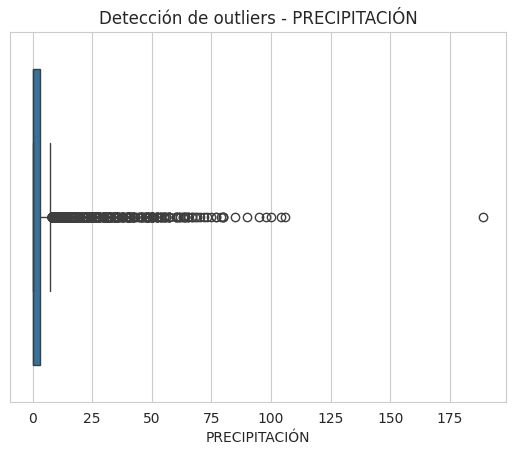

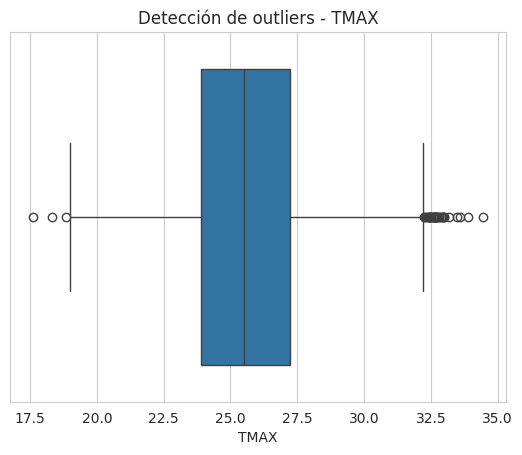

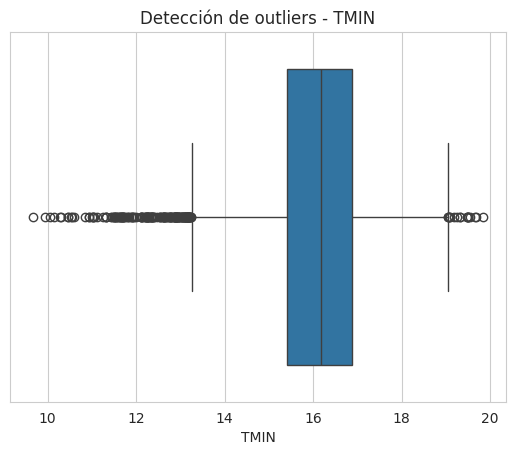

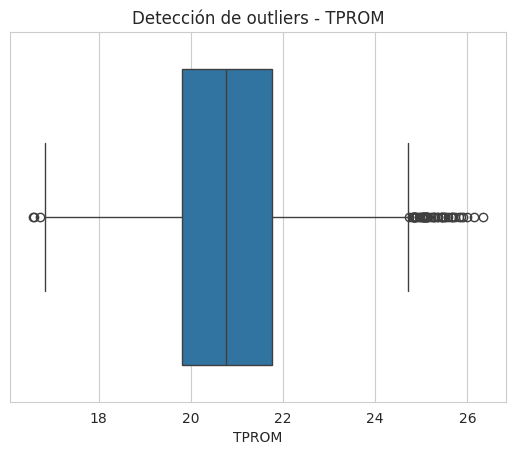

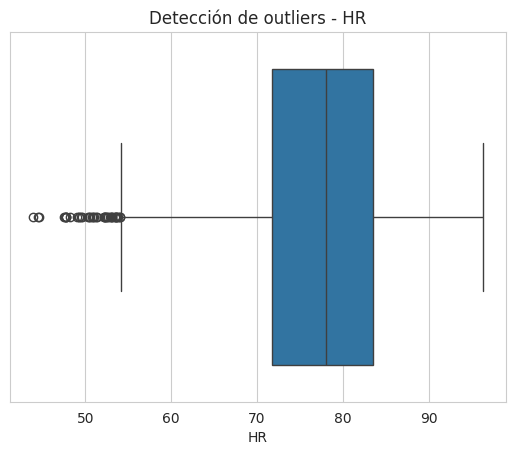

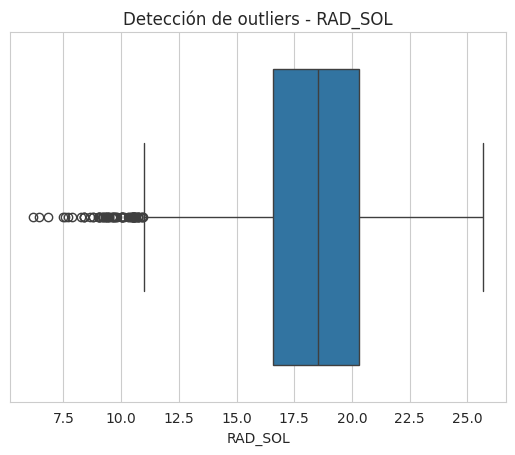

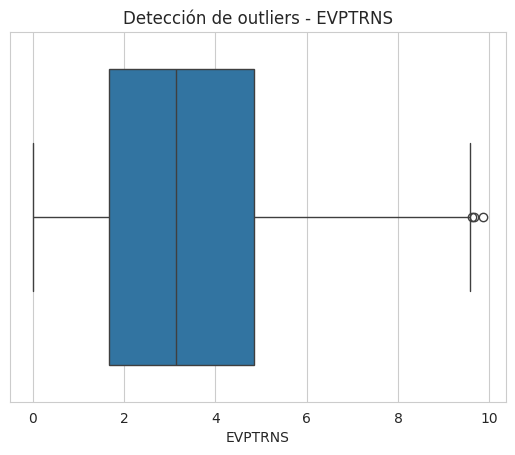

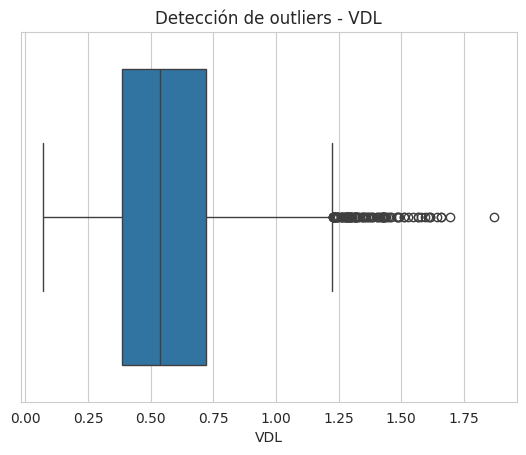

In [8]:
variables = [
    "PRECIPITACIÓN", "TMAX", "TMIN", "TPROM",
    "HR", "RAD_SOL", "EVPTRNS", "VDL"
]

for var in variables:
    plt.figure()
    sns.boxplot(x=df[var])
    plt.title(f"Detección de outliers - {var}")
    plt.show()


### Detección de valores atípicos

La detección de valores atípicos se realizó mediante diagramas de caja para cada una de las variables climáticas analizadas. Los resultados evidenciaron la presencia de valores extremos principalmente en la variable de precipitación, comportamiento esperado en climas tropicales caracterizados por la ocurrencia de eventos de lluvia intensa y esporádica. En las variables térmicas, de humedad relativa, radiación solar, evapotranspiración y déficit de presión de vapor, los valores extremos identificados se mantuvieron dentro de rangos físicamente plausibles y coherentes con las condiciones agroclimáticas de la región de estudio. En consecuencia, en esta etapa no se efectuó la eliminación de registros, dado que los valores atípicos detectados representan eventos climáticos reales y relevantes para el análisis, dejando su tratamiento para la fase posterior de limpieza y transformación de los datos, conforme a la metodología CRISP-DM.


In [9]:
# =====================================================
# EXPORTACIÓN DE DATOS LIMPIOS - CRISP-DM
# Fase: Preparación de los Datos (EDA + Reglas Físicas)
# =====================================================

from google.colab import files

# Nombre base de los archivos
base_name = "datos_limpios_diarios_cacao_crispdm_preparacion"

# Exportar a CSV
csv_path = f"{base_name}.csv"
df.to_csv(csv_path, index=False)

# Exportar a Excel
excel_path = f"{base_name}.xlsx"
df.to_excel(excel_path, index=False)

# Descargar archivos
files.download(csv_path)
files.download(excel_path)

print("Archivos exportados correctamente:")
print(csv_path)
print(excel_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivos exportados correctamente:
datos_limpios_diarios_cacao_crispdm_preparacion.csv
datos_limpios_diarios_cacao_crispdm_preparacion.xlsx
